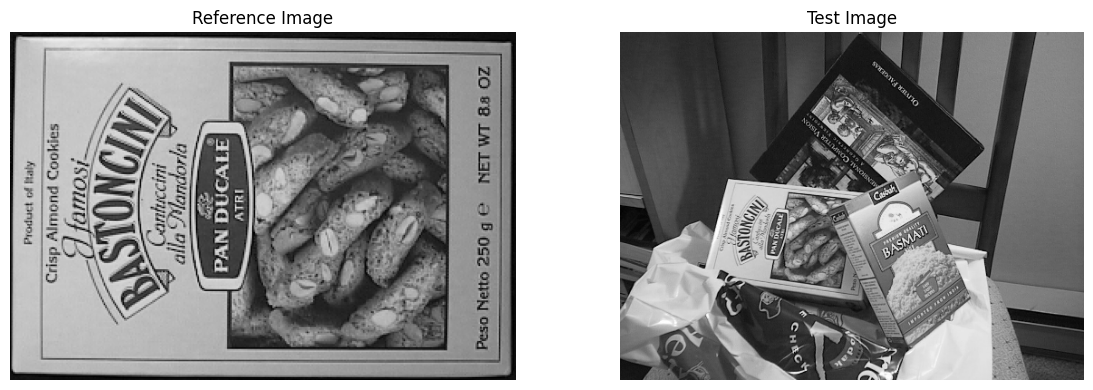

Reference keypoints: 604
Good matches: 74
Inliers: 72


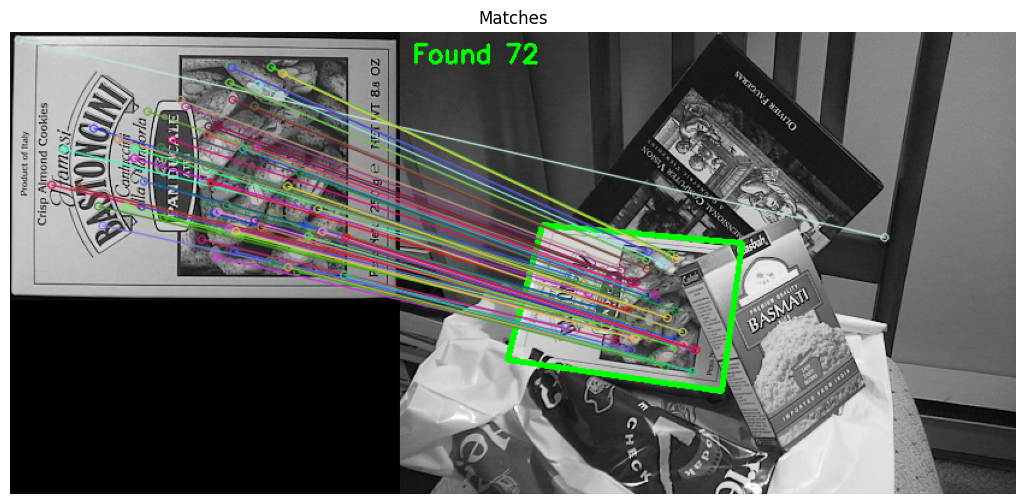

Total frames: 150
Object found in: 141 frames


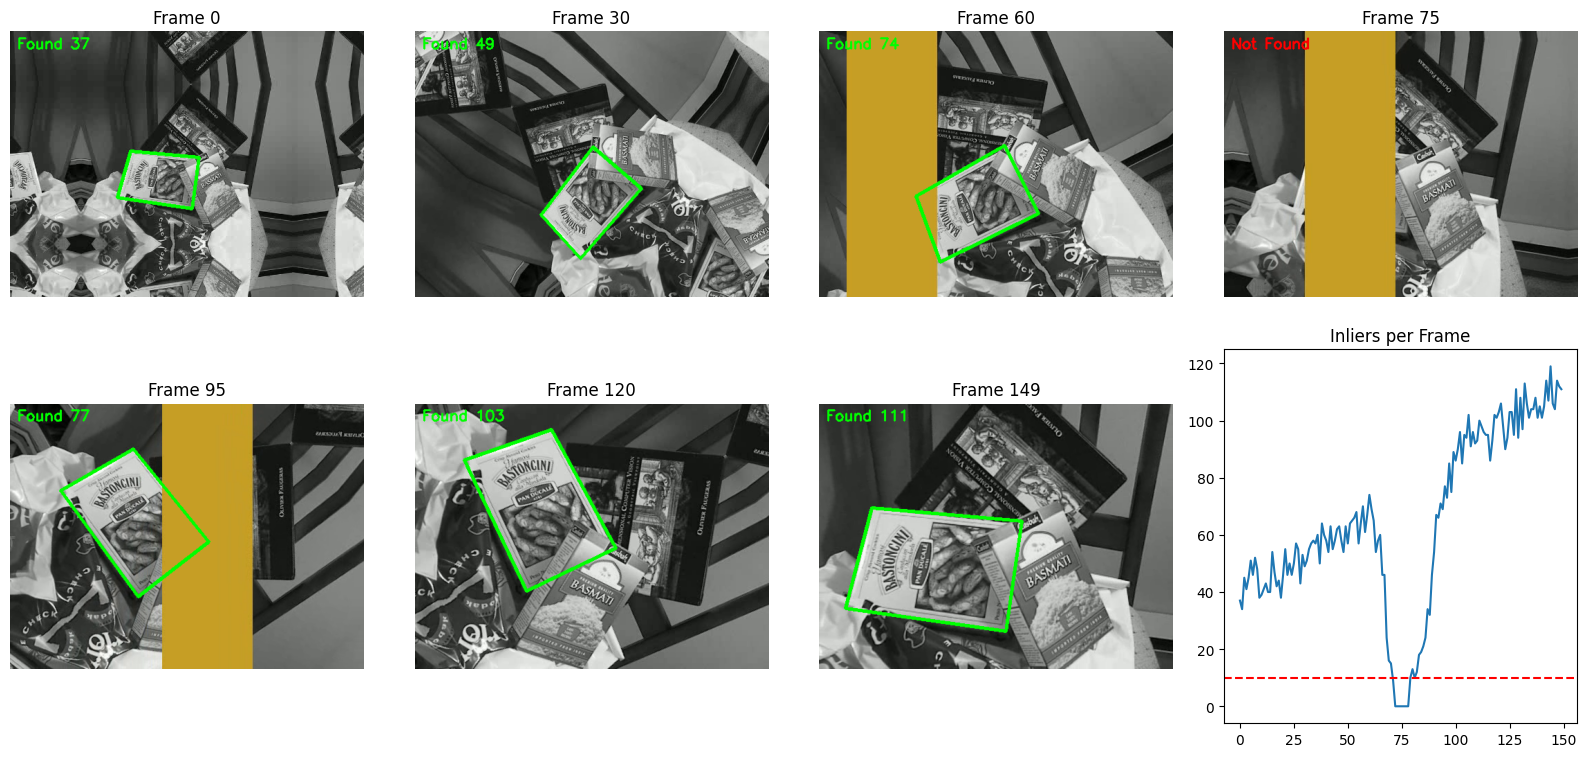

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read reference image and test image
reference = cv2.imread("box.png")
test_image = cv2.imread("box_in_scene.png")
if reference is None or test_image is None:
    print("Image not found, check the path")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(reference, cv2.COLOR_BGR2RGB))
plt.title("Reference Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
plt.title("Test Image")
plt.axis("off")

plt.tight_layout()
plt.show()

# Create SIFT detector
sift = cv2.SIFT_create()

# Keypoints and descriptors of reference image (only once)
ref_gray = cv2.cvtColor(reference, cv2.COLOR_BGR2GRAY)
kp1, des1 = sift.detectAndCompute(ref_gray, None)
print("Reference keypoints:", len(kp1))

# FLANN matcher
index_params = dict(algorithm=1, trees=5)
search_params = dict(checks=50)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# corners of reference image
h, w = ref_gray.shape
corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)

# function to find object in one image / frame
def find_object(frame):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    kp2, des2 = sift.detectAndCompute(gray, None)
    output = frame.copy()
    found = False
    inliers = 0
    good = []

    if des2 is not None and len(kp2) > 2:
        matches = flann.knnMatch(des1, des2, k=2)

        # Lowe's ratio test
        for m in matches:
            if len(m) == 2 and m[0].distance < 0.7 * m[1].distance:
                good.append(m[0])

        if len(good) >= 10:
            src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

            # Homography with RANSAC
            M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)
            if M is not None:
                inliers = int(mask.sum())
                box = cv2.perspectiveTransform(corners, M)
                if inliers >= 10 and cv2.isContourConvex(np.int32(box)):
                    found = True
                    # Draw bounding box
                    cv2.polylines(output, [np.int32(box)], True, (0, 255, 0), 3)

    if found:
        cv2.putText(output, "Found " + str(inliers), (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    else:
        cv2.putText(output, "Not Found", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    return output, found, inliers, kp2, good

# Test on the image first
result, found, inliers, kp2, good = find_object(test_image)
print("Good matches:", len(good))
print("Inliers:", inliers)

match_image = cv2.drawMatches(reference, kp1, result, kp2, good, None, flags=2)
plt.figure(figsize=(14, 6))
plt.imshow(cv2.cvtColor(match_image, cv2.COLOR_BGR2RGB))
plt.title("Matches")
plt.axis("off")
plt.show()

# Now run on video
cap = cv2.VideoCapture("test_video.mp4")
if not cap.isOpened():
    print("Video not found, check the path")

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# save result video
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter("result_video.mp4", fourcc, fps, (width, height))

frame_no = 0
found_count = 0
inliers_list = []
saved_frames = {}

while True:
    ret, frame = cap.read()
    if not ret:
        break

    result, found, inliers, kp2, good = find_object(frame)
    out.write(result)

    inliers_list.append(inliers)
    if found:
        found_count += 1

    # save some frames to show later
    if frame_no in [0, 30, 60, 75, 95, 120, 149]:
        saved_frames[frame_no] = result

    frame_no += 1

cap.release()
out.release()

print("Total frames:", frame_no)
print("Object found in:", found_count, "frames")

# Show some frames
plt.figure(figsize=(16, 8))
i = 1
for f in saved_frames:
    plt.subplot(2, 4, i)
    plt.imshow(cv2.cvtColor(saved_frames[f], cv2.COLOR_BGR2RGB))
    plt.title("Frame " + str(f))
    plt.axis("off")
    i += 1

plt.subplot(2, 4, 8)
plt.plot(inliers_list)
plt.axhline(10, color="r", linestyle="--")
plt.title("Inliers per Frame")

plt.tight_layout()
plt.show()